<a href="https://colab.research.google.com/github/VasilievNichita/IA_LABS/blob/main/Lab_5_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#  Shoe Image Classification – CNN (Keras / TensorFlow)
#  Dataset: Shoes Classification Dataset | 13k Images (Kaggle)
#  Classes: boots, flip flops, loafers, sandals, sneakers
# ================================================================

# ----------------------------------------------------------------
#  1. Install dependencies
# ----------------------------------------------------------------

!pip install -q kagglehub

In [2]:
#  2. Imports
# ----------------------------------------------------------------

import os
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report

import kagglehub

In [3]:
import os
import pathlib

# 3. Скачиваем датасет
path = kagglehub.dataset_download("utkarshsaxenadn/shoes-classification-dataset-13k-images")
print("Path to dataset files:", path)

data_dir = pathlib.Path(path)

# Посмотрим, какие папки есть внутри на самом деле
print("Содержимое папки датасета:", os.listdir(data_dir))

# В этом датасете структура обычно такая: внутри папка 'Shoes', а в ней 'Train', 'Test', 'Valid'
# Либо папки классов лежат прямо в корне.
# Давай попробуем автоматически найти нужные директории:

def find_dir(root, target_name):
    for p in root.rglob('*'):
        if p.is_dir() and p.name.lower() == target_name.lower():
            return p
    return None

train_dir = find_dir(data_dir, 'train')
test_dir  = find_dir(data_dir, 'test')
valid_dir = find_dir(data_dir, 'valid')

# Если структуры train/test/valid нет, и папки классов лежат прямо в корне:
if train_dir is None:
    print("Структура train/test/valid не найдена. Проверяем папки классов в корне...")
    train_dir = data_dir
    # В этом случае придется делить данные вручную или использовать validation_split в ImageDataGenerator

print(f"Итоговые пути:\n Train: {train_dir}\n Test: {test_dir}\n Valid: {valid_dir}")

# Теперь пробуем получить классы
if train_dir:
    class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(train_dir / d)])
    num_classes = len(class_names)
    print(f"\nНайдено классов: {num_classes}")
    print(f"Классы: {class_names}")

100%|██████████| 276M/276M [00:18<00:00, 15.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/utkarshsaxenadn/shoes-classification-dataset-13k-images/versions/2
Содержимое папки датасета: ['Shoes Dataset']
Итоговые пути:
 Train: /root/.cache/kagglehub/datasets/utkarshsaxenadn/shoes-classification-dataset-13k-images/versions/2/Shoes Dataset/Train
 Test: /root/.cache/kagglehub/datasets/utkarshsaxenadn/shoes-classification-dataset-13k-images/versions/2/Shoes Dataset/Test
 Valid: /root/.cache/kagglehub/datasets/utkarshsaxenadn/shoes-classification-dataset-13k-images/versions/2/Shoes Dataset/Valid

Найдено классов: 5
Классы: ['Ballet Flat', 'Boat', 'Brogue', 'Clog', 'Sneaker']


In [4]:
# ----------------------------------------------------------------
# 4. Data preprocessing and augmentation
# ----------------------------------------------------------------

IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

valid_generator = test_datagen.flow_from_directory(
    valid_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 10000 images belonging to 5 classes.
Found 2500 images belonging to 5 classes.
Found 1215 images belonging to 5 classes.


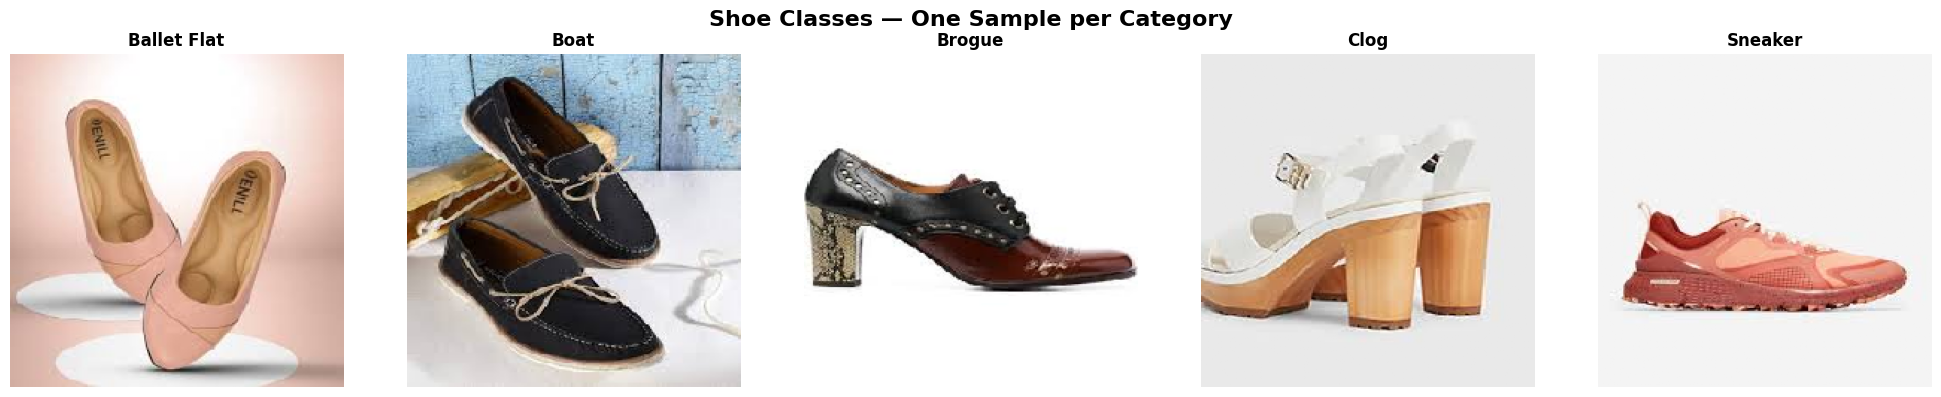

In [5]:
#  5. Visualize one sample per class
# ----------------------------------------------------------------

fig, axes = plt.subplots(1, num_classes, figsize=(4 * num_classes, 4))

for i, name in enumerate(class_names):
 img_path = train_dir / name / os.listdir(train_dir / name)[0]
 img = tf.keras.preprocessing.image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
 axes[i].imshow(tf.keras.preprocessing.image.img_to_array(img) / 255.0)
 axes[i].set_title(name, fontsize=12, fontweight='bold')
 axes[i].axis('off')

plt.suptitle('Shoe Classes — One Sample per Category', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('shoe_examples.png', dpi=150, bbox_inches='tight')
plt.show()


In [6]:
#  6. Build CNN model
# ----------------------------------------------------------------

model = Sequential()

# Block 1
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.25))

# Block 2
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.25))

# Block 3
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.3))

# Block 4
model.add(Conv2D(256, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.3))

# Classifier
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

model.compile(
optimizer='adam',
 loss='categorical_crossentropy',
 metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 19,399,877 (74.00 MB)

 Trainable params: 19,397,893 (74.00 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [7]:
#  7. Train the model
# ----------------------------------------------------------------

EPOCHS = 10

history = model.fit(
 train_generator,
 epochs=EPOCHS,
 validation_data=valid_generator,
 verbose=1
)


Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 166s 465ms/step - accuracy: 0.2661 - loss: 2.1175 - val_accuracy: 0.2216 - val_loss: 1.7904
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 129s 410ms/step - accuracy: 0.3115 - loss: 1.6506 - val_accuracy: 0.2944 - val_loss: 1.4927
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 127s 405ms/step - accuracy: 0.3395 - loss: 1.4998 - val_accuracy: 0.2940 - val_loss: 1.6013
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 124s 397ms/step - accuracy: 0.3821 - loss: 1.4308 - val_accuracy: 0.3636 - val_loss: 1.4831
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 125s 400ms/step - accuracy: 0.4058 - loss: 1.3924 - val_accuracy: 0.3916 - val_loss: 1.3852
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 127s 407ms/step - accuracy: 0.4199 - loss: 1.3658 - val_accuracy: 0.3204 - val_loss: 1.7986
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 124s 396ms/step - accuracy: 0.4438 - loss: 1.3371 - val_accuracy: 0.3548 - val_loss: 1.4951
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 124s 395ms/step - accuracy: 0.4571 -

In [8]:
#  8. Evaluate on test set
# ----------------------------------------------------------------

test_loss, test_accuracy = model.evaluate(test_generator, verbose=0)

print(f"\nTest Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")



Test Loss:     1.3251
Test Accuracy: 0.4691 (46.91%)


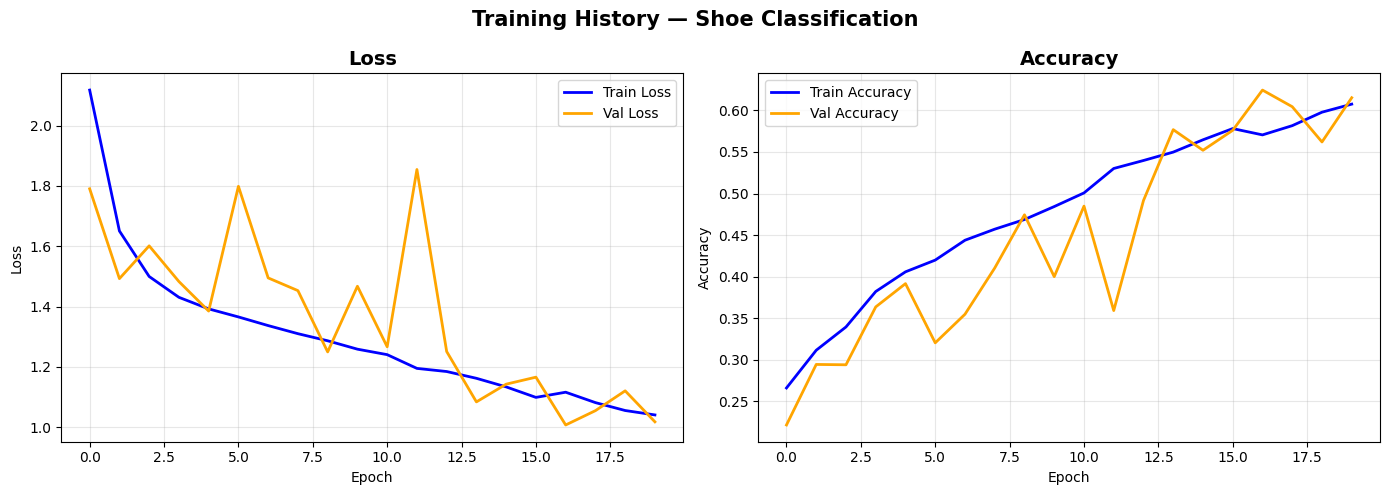

In [10]:
#  9. Training history plots
# ----------------------------------------------------------------

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'], label='Train Loss', linewidth=2, color='blue')
ax1.plot(history.history['val_loss'], label='Val Loss', linewidth=2, color='orange')
ax1.set_title('Loss', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2, color='blue')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy',  linewidth=2, color='orange')
ax2.set_title('Accuracy', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Training History — Shoe Classification', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()


38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step


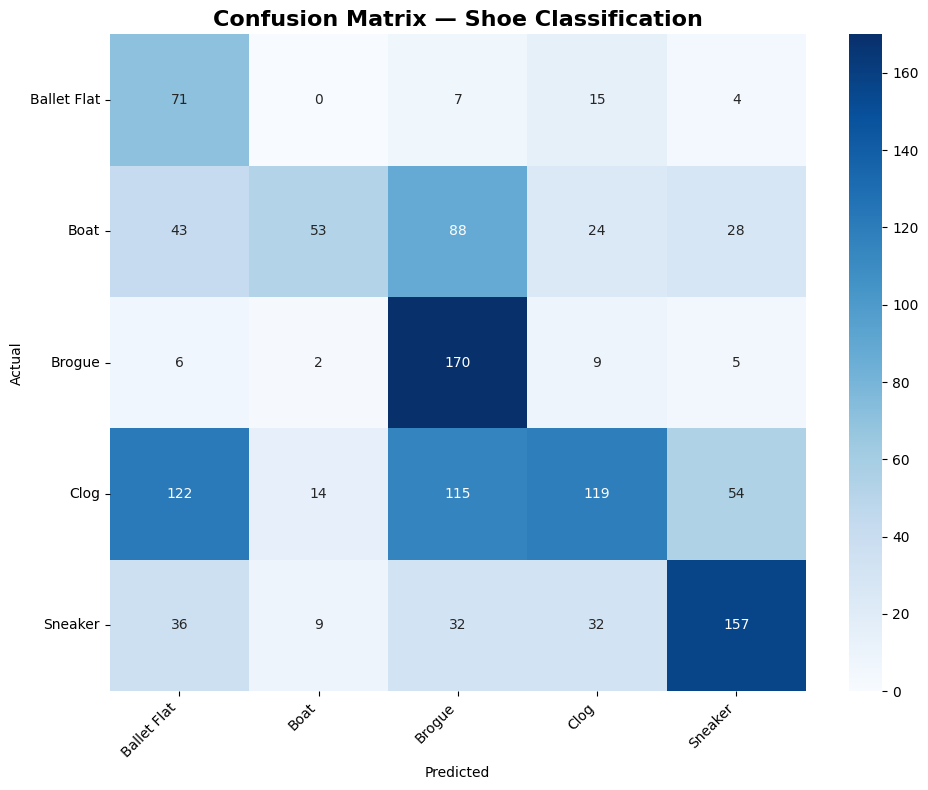

              precision    recall  f1-score   support

 Ballet Flat       0.26      0.73      0.38        97
        Boat       0.68      0.22      0.34       236
      Brogue       0.41      0.89      0.56       192
        Clog       0.60      0.28      0.38       424
     Sneaker       0.63      0.59      0.61       266

    accuracy                           0.47      1215
   macro avg       0.52      0.54      0.45      1215
weighted avg       0.56      0.47      0.45      1215



In [11]:
#  10. Confusion matrix
# ----------------------------------------------------------------

test_generator.reset()
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)
y_test = test_generator.classes

label_map = {v: k for k, v in test_generator.class_indices.items()}
target_names = [label_map[i] for i in range(num_classes)]

cm = confusion_matrix(y_test, predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix — Shoe Classification', fontsize=16, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print(classification_report(y_test, predicted_classes, target_names=target_names))


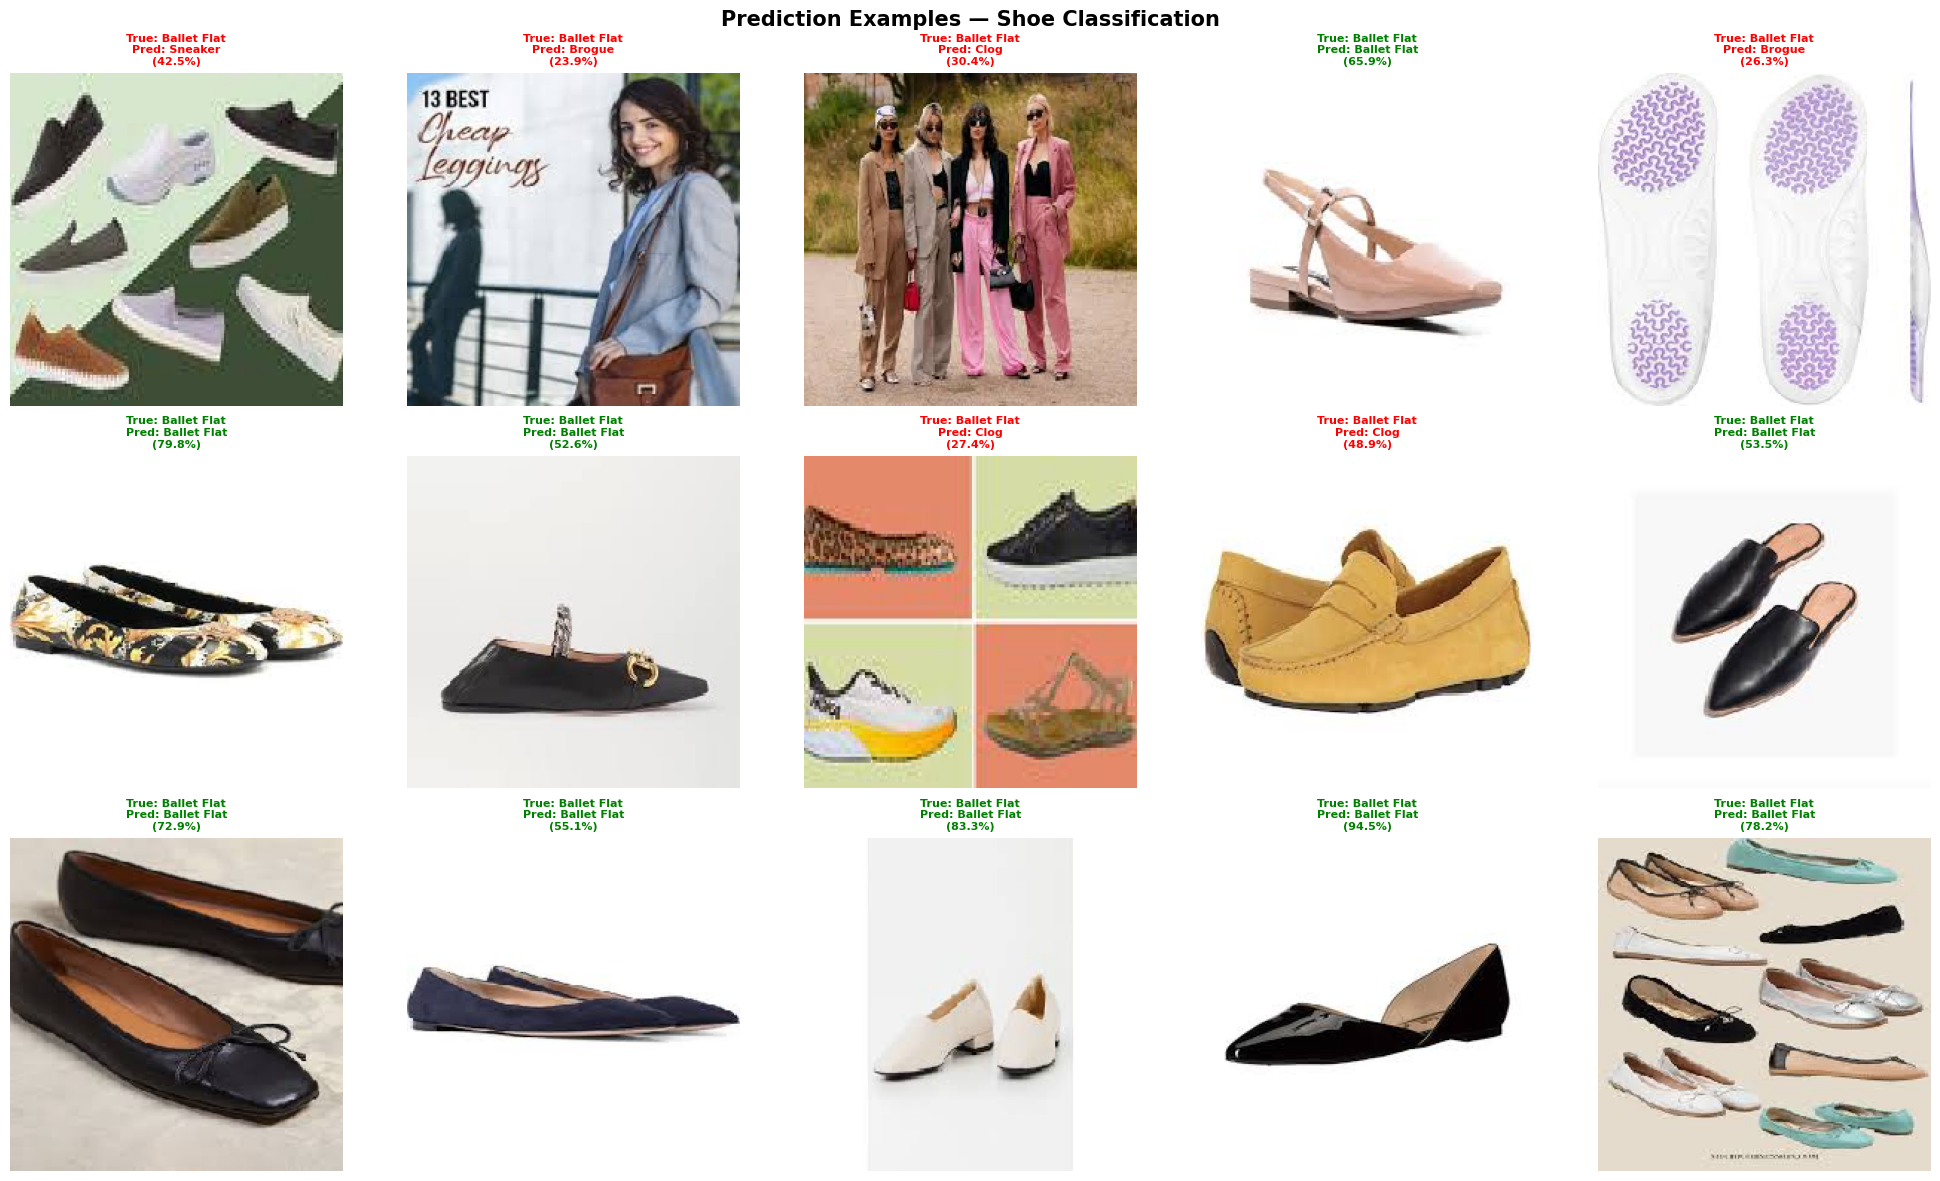

In [12]:
#  11. Prediction examples
# ----------------------------------------------------------------

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

test_generator.reset()
test_images, test_labels_onehot = next(test_generator)
batch_preds = model.predict(test_images, verbose=0)

for i in range(min(15, len(test_images))):
 true_label = np.argmax(test_labels_onehot[i])
 pred_label = np.argmax(batch_preds[i])
 confidence = batch_preds[i][pred_label] * 100

 axes[i].imshow(test_images[i])
 color = 'green' if true_label == pred_label else 'red'
 axes[i].set_title(
 f'True: {label_map[true_label]}\nPred: {label_map[pred_label]}\n({confidence:.1f}%)',
 fontsize=8, color=color, fontweight='bold')
 axes[i].axis('off')

plt.suptitle('Prediction Examples — Shoe Classification', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('predictions_examples.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
#  12. Error analysis
# ----------------------------------------------------------------

errors_idx = np.where(y_test != predicted_classes)[0]
correct_idx = np.where(y_test == predicted_classes)[0]

print(f"Total test images:       {len(y_test)}")
print(f"Correctly classified:     {len(correct_idx)} ({len(correct_idx)/len(y_test)*100:.2f}%)")
print(f"Misclassified:           {len(errors_idx)} ({len(errors_idx)/len(y_test)*100:.2f}%)")

error_pairs = {}
for idx in errors_idx:
 pair = (y_test[idx], predicted_classes[idx])
 error_pairs[pair] = error_pairs.get(pair, 0) + 1

sorted_errors = sorted(error_pairs.items(), key=lambda x: x[1], reverse=True)[:10]

print("\nMost common mistakes:")
for (true, pred), count in sorted_errors:
 print(f" {target_names[true]} -> {target_names[pred]}: {count}x")

Total test images:       1215
Correctly classified:     570 (46.91%)
Misclassified:           645 (53.09%)

Most common mistakes:
 Clog -> Ballet Flat: 122x
 Clog -> Brogue: 115x
 Boat -> Brogue: 88x
 Clog -> Sneaker: 54x
 Boat -> Ballet Flat: 43x
 Sneaker -> Ballet Flat: 36x
 Sneaker -> Clog: 32x
 Sneaker -> Brogue: 32x
 Boat -> Sneaker: 28x
 Boat -> Clog: 24x
